In [ ]:
#importing weather data for rostock warnemünde
import pandas as pd
import requests
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=weatherdataforcities&start=2019-01-01&end=2023-12-31&cityName=Rostock Warnem-u00fcnde"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    Rost_df = pd.DataFrame.from_dict(data , orient='index')

    # Reset the index to convert the timestamp to a column
    Rost_df.reset_index(inplace=True)

else:
    print("Failed to fetch data. Status code:", response.status_code)





In [ ]:

# drop unwanted columns
Rost_df =  Rost_df.drop(columns = ["index", "time","snow","cityName"])
Rost_df
Rost_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   temp    43824 non-null  float64
 1   dwpt    43824 non-null  float64
 2   rhum    43824 non-null  float64
 3   prcp    43824 non-null  float64
 4   wdir    43824 non-null  float64
 5   wspd    43824 non-null  float64
 6   wpgt    43824 non-null  float64
 7   pres    43824 non-null  float64
 8   tsun    42732 non-null  float64
 9   coco    43578 non-null  float64
dtypes: float64(10)
memory usage: 3.3 MB


In [ ]:
Rost_df.head()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
0,8.1,4.9,80.0,0.1,250.0,25.2,51.0,1021.7,0.0,7.0
1,8.3,4.7,78.0,0.0,250.0,27.4,51.0,1020.5,0.0,8.0
2,8.3,4.7,78.0,0.0,250.0,25.6,50.0,1019.5,0.0,4.0
3,8.1,4.9,80.0,0.0,250.0,27.0,55.0,1017.9,0.0,7.0
4,7.8,5.1,83.0,0.0,250.0,28.1,58.0,1016.2,0.0,7.0


In [ ]:
#Checking for null values
Rost_df.isnull().sum()

temp       0
dwpt       0
rhum       0
prcp       0
wdir       0
wspd       0
wpgt       0
pres       0
tsun    1092
coco     246
dtype: int64

In [ ]:
# find the percentage of missing values in each feature
Rost_df.isnull().sum()/len(Rost_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.000000
pres    0.000000
tsun    2.491785
coco    0.561336
dtype: float64

In [ ]:
mask_nntsun = Rost_df['tsun'].isnull()
Rost_df[mask_nntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
765,-0.1,-2.0,87.0,0.0,110.0,11.1,24.1,996.7,NaN,4.0
766,0.1,-2.0,86.0,0.0,111.0,11.1,24.1,996.7,NaN,4.0
767,0.0,-1.9,87.0,0.0,110.0,11.1,22.2,996.8,NaN,4.0
768,0.1,-1.7,88.0,0.0,105.0,9.3,20.4,996.9,NaN,4.0
769,0.0,-1.4,90.0,0.0,102.0,9.3,18.5,997.0,NaN,4.0
...,...,...,...,...,...,...,...,...,...,...
40161,17.6,15.4,87.0,0.0,210.0,12.2,28.0,994.2,NaN,8.0
40162,18.8,14.5,76.0,0.0,220.0,13.7,27.0,994.1,NaN,4.0
40163,19.2,14.2,73.0,0.0,240.0,15.1,30.0,994.3,NaN,4.0
40164,20.2,14.3,69.0,0.0,270.0,18.7,44.0,994.3,NaN,8.0


In [ ]:
#Using Linear Regression Imputation to fill missing values in the tsun feature
from sklearn.linear_model import LinearRegression

# seperate the null  values of the tsun feature
test =  Rost_df[Rost_df["tsun"].isnull()]
X_test = test.drop(columns = ["tsun","coco","wpgt"] )

#Dropping the null values from the dataset
train = Rost_df.dropna()
#Splitting the train data into target and feature
X_train= train.drop(columns = ["tsun","coco","wpgt"])
y_train = train["tsun"]

#Calling the linear regression model
lr = LinearRegression()
#Fitting the tranining data in to the model
lr.fit(X_train, y_train)
#Predicting the missing tsun values
y_pred = lr.predict(X_test)

#Replacing the missing values with the model prediction
Rost_df.loc[Rost_df.tsun.isnull(),"tsun"] = y_pred






In [ ]:
#Check if missing values still exists for the tsun feature
Rost_df.isnull().sum()/len(Rost_df) *100

temp    0.000000
dwpt    0.000000
rhum    0.000000
prcp    0.000000
wdir    0.000000
wspd    0.000000
wpgt    0.000000
pres    0.000000
tsun    0.000000
coco    0.561336
dtype: float64

In [ ]:

# seperate the null  values of the coco feature

test_coco =  Rost_df[Rost_df["coco"].isnull()]
X_test_coco = test_coco.drop("coco", axis = 1)

train_coco = Rost_df.dropna()
X_train_coco= train_coco.drop(columns = "coco")
y_train_coco = train_coco["coco"]
lr2 = LinearRegression()
lr2.fit(X_train_coco, y_train_coco)
#Predicting the missing tsun values
y_pred2 = lr2.predict(X_test_coco)

#Replacing the missing values with the model prediction
Rost_df.loc[Rost_df.coco.isnull(),"coco"] = y_pred2



In [ ]:
#Check if missing values still exists for the coco feature
Rost_df.isnull().sum()/len(Rost_df) *100


temp    0.0
dwpt    0.0
rhum    0.0
prcp    0.0
wdir    0.0
wspd    0.0
wpgt    0.0
pres    0.0
tsun    0.0
coco    0.0
dtype: float64

In [ ]:

Rost_df.isnull().sum()

temp    0
dwpt    0
rhum    0
prcp    0
wdir    0
wspd    0
wpgt    0
pres    0
tsun    0
coco    0
dtype: int64

In [ ]:
# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = Rost_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
Rost_df.describe()

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
count,43824.000000,43824.000000,43824.000000,43824.000000,43824.00000,43824.000000,43824.000000,43824.000000,43824.000000,43824.000000
mean,10.732829,6.555310,76.906467,0.069875,201.08007,17.270215,29.337607,1014.523811,13.284273,4.071550
std,6.665365,5.955294,13.380886,0.450015,86.31118,9.871057,13.993375,10.494986,22.431283,2.635798
min,-7.800000,-14.300000,18.000000,0.000000,2.00000,0.700000,2.000000,974.100000,-9.493159,1.000000
25%,5.400000,2.100000,69.000000,0.000000,140.00000,10.400000,19.000000,1007.900000,0.000000,2.000000
50%,10.300000,6.400000,79.000000,0.000000,210.00000,14.800000,27.000000,1015.200000,0.000000,4.000000
75%,16.100000,11.300000,87.000000,0.000000,274.25000,22.000000,37.000000,1021.400000,20.000000,4.000000
max,37.800000,20.700000,100.000000,18.900000,360.00000,81.700000,111.000000,1048.300000,60.000000,25.000000


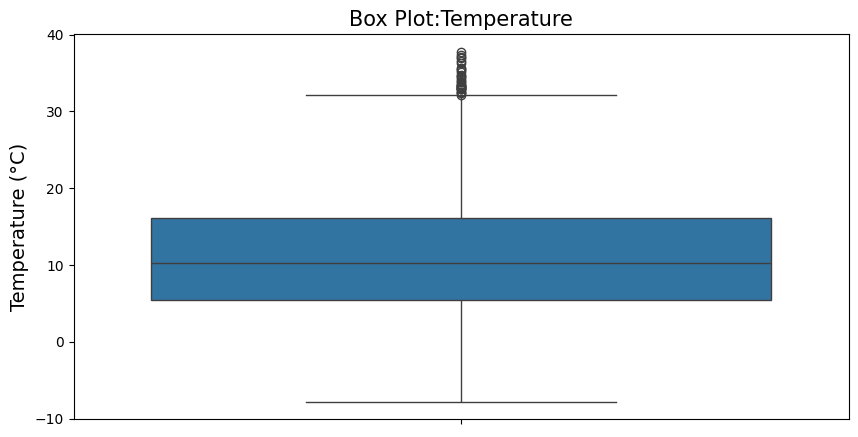

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.temp)
plt.title('Box Plot:Temperature', fontsize=15)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.show()

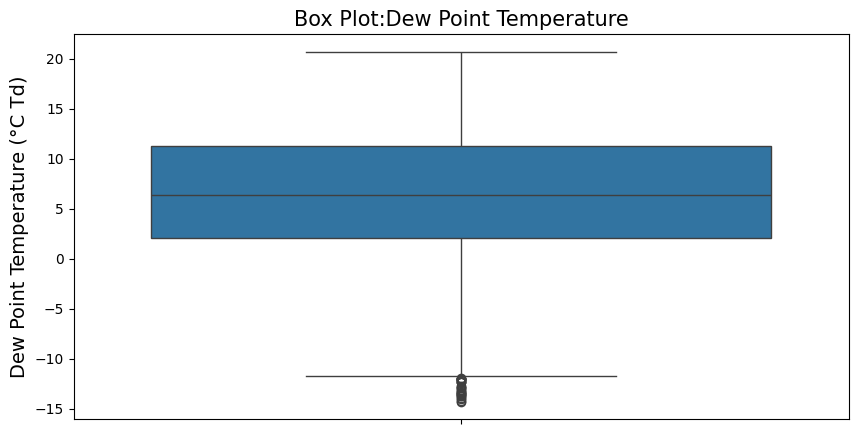

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.dwpt)
plt.title('Box Plot:Dew Point Temperature', fontsize=15)
plt.ylabel('Dew Point Temperature (°C Td)', fontsize=14)
plt.show()

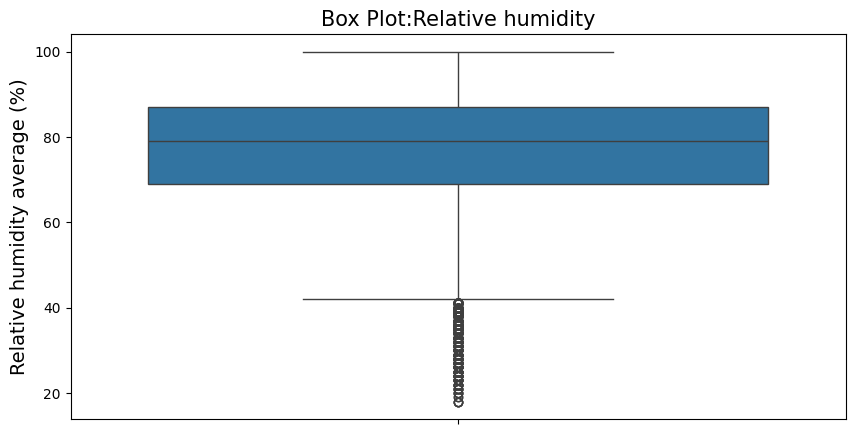

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.rhum)
plt.title('Box Plot:Relative humidity', fontsize=15)
plt.ylabel('Relative humidity average (%)', fontsize=14)
plt.show()

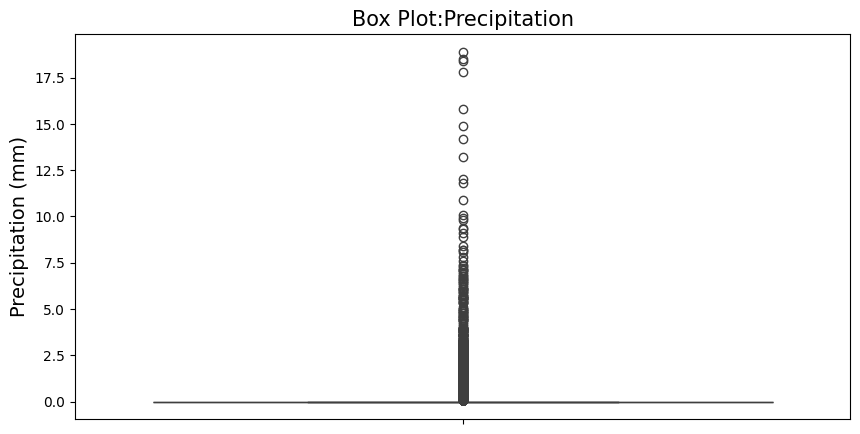

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.prcp)
plt.title('Box Plot:Precipitation', fontsize=15)
plt.ylabel('Precipitation (mm)', fontsize=14)
plt.show()

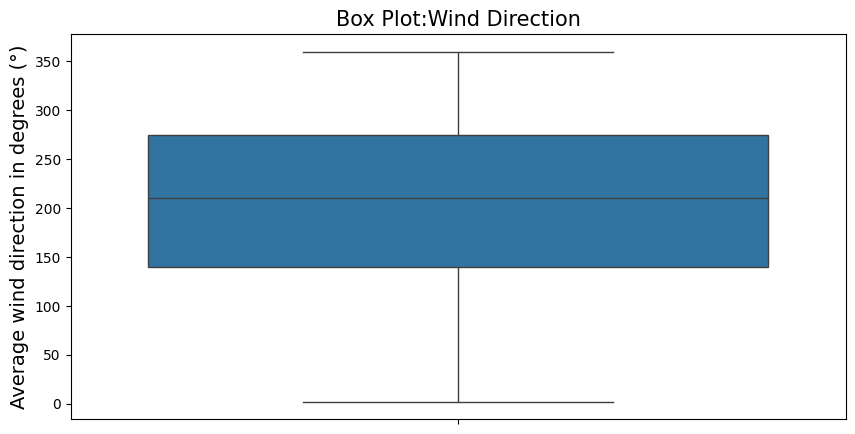

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.wdir)
plt.title('Box Plot:Wind Direction', fontsize=15)
plt.ylabel('Average wind direction in degrees (°)', fontsize=14)
plt.show()

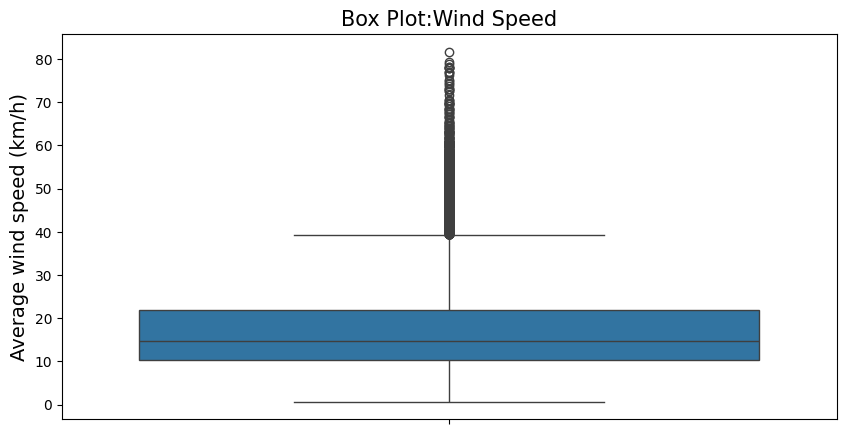

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.wspd)
plt.title('Box Plot:Wind Speed', fontsize=15)
plt.ylabel('Average wind speed (km/h)', fontsize=14)
plt.show()

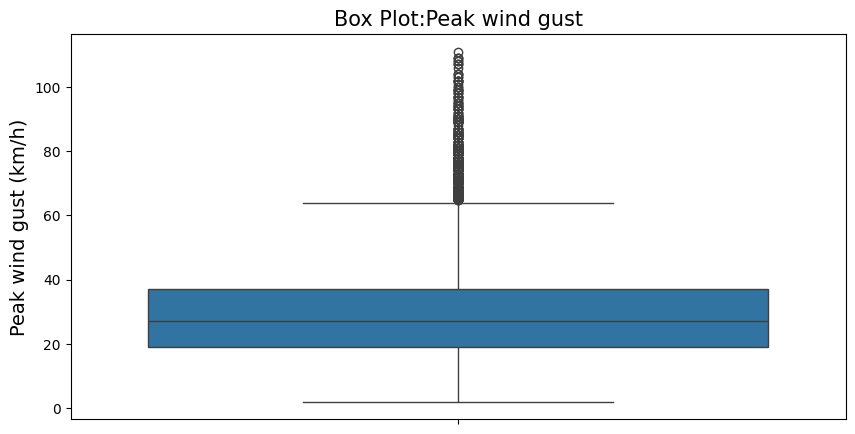

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.wpgt)
plt.title('Box Plot:Peak wind gust', fontsize=15)
plt.ylabel('Peak wind gust (km/h)', fontsize=14)
plt.show()

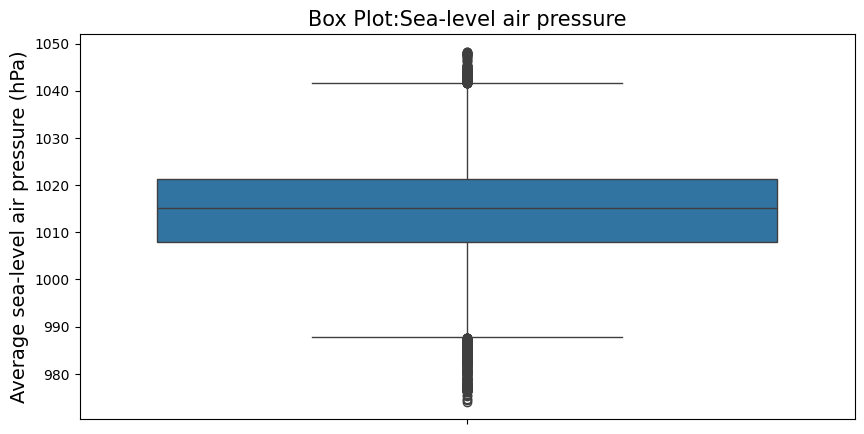

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.pres)
plt.title('Box Plot:Sea-level air pressure', fontsize=15)
plt.ylabel('Average sea-level air pressure (hPa)', fontsize=14)
plt.show()

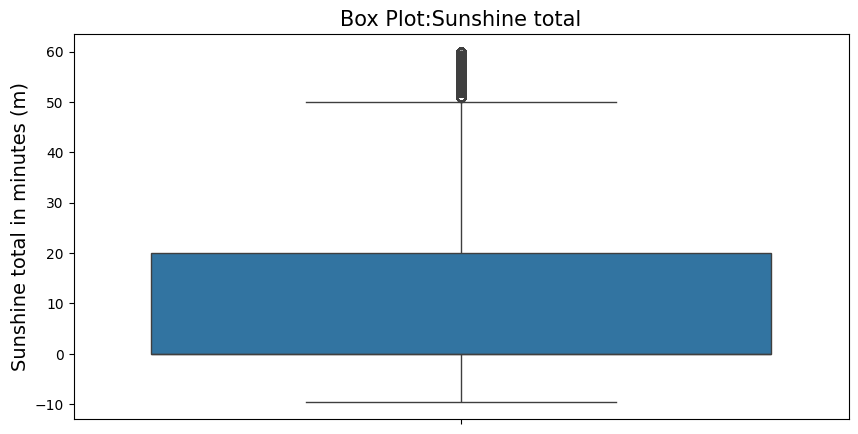

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.tsun)
plt.title('Box Plot:Sunshine total', fontsize=15)
plt.ylabel('Sunshine total in minutes (m)', fontsize=14)
plt.show()

In [ ]:
Rost_df["tsun"].max()

60.0

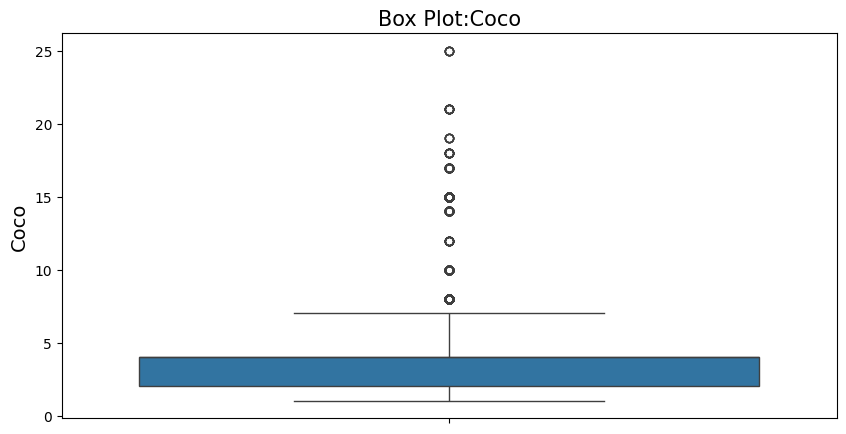

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(Rost_df.coco)
plt.title('Box Plot:Coco', fontsize=15)
plt.ylabel('Coco', fontsize=14)
plt.show()

In [ ]:
mask_ntsun = Rost_df['tsun'] > 0.0
Rost_df[mask_ntsun]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
9,6.9,3.3,78.0,0.0,280.0,49.3,64.0,1013.2,19.0,7.0
10,6.9,3.5,79.0,0.0,280.0,52.6,73.0,1013.3,28.0,4.0
11,6.9,3.1,77.0,0.0,280.0,54.7,72.0,1012.4,32.0,2.0
12,6.5,2.8,77.0,0.0,290.0,60.5,86.0,1011.6,48.0,2.0
13,6.5,2.2,74.0,0.0,280.0,63.4,89.0,1011.0,31.0,4.0
...,...,...,...,...,...,...,...,...,...,...
43785,5.8,3.0,82.0,0.0,240.0,20.5,46.0,1006.3,1.0,4.0
43786,5.8,3.0,82.0,0.0,240.0,16.9,37.0,1007.4,1.0,4.0
43787,6.1,3.3,82.0,0.0,240.0,17.3,39.0,1007.8,4.0,8.0
43788,6.1,2.7,79.0,0.0,240.0,18.4,44.0,1008.0,34.0,8.0


In [ ]:
mask_tsun = Rost_df['tsun'] == 0.0
mask_prcp = Rost_df['prcp'] ==0.0
Rost_df[mask_tsun & mask_prcp]

,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco
1,8.3,4.7,78.0,0.0,250.0,27.4,51.0,1020.5,0.0,8.0
2,8.3,4.7,78.0,0.0,250.0,25.6,50.0,1019.5,0.0,4.0
3,8.1,4.9,80.0,0.0,250.0,27.0,55.0,1017.9,0.0,7.0
4,7.8,5.1,83.0,0.0,250.0,28.1,58.0,1016.2,0.0,7.0
15,5.8,1.7,75.0,0.0,290.0,60.8,86.0,1010.3,0.0,8.0
...,...,...,...,...,...,...,...,...,...,...
43814,6.8,3.9,82.0,0.0,150.0,18.7,42.0,1001.4,0.0,8.0
43815,6.8,3.8,81.0,0.0,140.0,22.3,37.0,1000.8,0.0,4.0
43818,7.0,4.3,83.0,0.0,150.0,17.6,28.0,1000.1,0.0,8.0
43822,6.8,5.3,90.0,0.0,180.0,10.8,23.0,1001.2,0.0,8.0


In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Number of neighbors for LOF
n_neighbors = 20
contamination = 0.10
# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}

# Apply LOF to each feature
for feature in Rost_df.columns:
# Reshape the data for LOF
 X = Rost_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in rostock warnemünde weather in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in rostock warnemünde weather in temp: 0.29%
Percentage of outliers in rostock warnemünde weather in dwpt: 0.24%
Percentage of outliers in rostock warnemünde weather in rhum: 0.01%
Percentage of outliers in rostock warnemünde weather in prcp: 0.11%
Percentage of outliers in rostock warnemünde weather in wdir: 0.27%
Percentage of outliers in rostock warnemünde weather in wspd: 0.32%
Percentage of outliers in rostock warnemünde weather in wpgt: 0.38%
Percentage of outliers in rostock warnemünde weather in pres: 0.62%
Percentage of outliers in rostock warnemünde weather in tsun: 1.68%
Percentage of outliers in rostock warnemünde weather in coco: 0.26%


USING NAIVE BAYES FOR THE WEATHER DATASET


In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm


# Extract features
X = Rost_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = gnb.var_
likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_Rost_df= Rost_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(Rost_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in Rost_df.columns:
    feature_anomalies_count = (anomalies_Rost_df[feature] != Rost_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 4383
Percentage of anomalies for each feature:
temp: 9.94%
dwpt: 9.93%
rhum: 9.83%
prcp: 2.54%
wdir: 9.39%
wspd: 9.87%
wpgt: 9.80%
pres: 9.97%
tsun: 4.81%
coco: 8.77%


NAIVE BAYES 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm



# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in Rost_df.columns:
    # Extract the feature values
    X = Rost_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(Rost_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: temp
  Number of anomalies detected: 1761
  Percentage of anomalies: 4.02%
Feature: dwpt
  Number of anomalies detected: 1757
  Percentage of anomalies: 4.01%
Feature: rhum
  Number of anomalies detected: 2264
  Percentage of anomalies: 5.17%
Feature: prcp
  Number of anomalies detected: 1731
  Percentage of anomalies: 3.95%
Feature: wdir
  Number of anomalies detected: 2194
  Percentage of anomalies: 5.01%
Feature: wspd
  Number of anomalies detected: 2940
  Percentage of anomalies: 6.71%
Feature: wpgt
  Number of anomalies detected: 2424
  Percentage of anomalies: 5.53%
Feature: pres
  Number of anomalies detected: 2651
  Percentage of anomalies: 6.05%
Feature: tsun
  Number of anomalies detected: 6204
  Percentage of anomalies: 14.16%
Feature: coco
  Number of anomalies detected: 708
  Percentage of anomalies: 1.62%


In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(Rost_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: temp
Threshold: 0.2660
Anomalies detected: 1456/43824 (3.32%)
----------------------------------------
Feature: dwpt
Threshold: 0.2616
Anomalies detected: 1430/43824 (3.26%)
----------------------------------------
Feature: rhum
Threshold: 2.0175
Anomalies detected: 1891/43824 (4.31%)
----------------------------------------
Feature: prcp
Threshold: 0.5535
Anomalies detected: 758/43824 (1.73%)
----------------------------------------
Feature: wdir
Threshold: 127.4442
Anomalies detected: 2433/43824 (5.55%)
----------------------------------------
Feature: wspd
Threshold: 3.2529
Anomalies detected: 1662/43824 (3.79%)
----------------------------------------
Feature: wpgt
Threshold: 5.5882
Anomalies detected: 1742/43824 (3.97%)
----------------------------------------
Feature: pres
Threshold: 14.4731
Anomalies detected: 2149/43824 (4.90%)
----------------------------------------
Feature: tsun
Threshold: 26.5649
Anomalies detected: 2691/43824 (6.14%)
------------------------------

AUTOENCODER FOR WEATHER

In [ ]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential



# #to save all features
# features_auto_w = Rost_df.columns.tolist()


# # DataFrame to store anomaly scores for each feature
# anomaly_scores_auto_w = pd.DataFrame(index=Rost_df.index)

# # Loop through each feature
# for feature in features_auto_w :
#     # Scale the feature data
#     scaler = MinMaxScaler()
#     scaled_feature_auto_w  = scaler.fit_transform(Rost_df[[feature]])

#     # Define the autoencoder model
#     model_auto_w  = Sequential([
#         Dense(32, activation='relu', input_shape=(1,)),
#         Dense(16, activation='relu'),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])

#     model_auto_w .compile(optimizer='adam', loss='mean_squared_error')

#      #Train the autoencoder
#     model_auto_w.fit(scaled_feature_auto_w , scaled_feature_auto_w , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

#     # Get reconstruction loss
#     reconstructed_feature_auto_w  = model_auto_w.predict(scaled_feature_auto_w )
#     reconstruction_loss_auto_w  = np.mean(np.square(scaled_feature_auto_w  - reconstructed_feature_auto_w ), axis=1)

#     # Store the reconstruction loss (anomaly score) in the DataFrame
#     anomaly_scores_auto_w [feature] = reconstruction_loss_auto_w



1370/1370 [==============================] - 2s 1ms/step


In [ ]:

# print(reconstruction_loss_auto_w)
# # Calculate the threshold as the 90th percentile of the reconstruction loss
# threshold_auto_w = np.percentile(reconstruction_loss_auto_w, 90)

#     # Identify anomalies
# anomalies_auto_w = reconstruction_loss_auto_w > threshold_auto_w

# for feature in features_auto_w:
#     anomalies_auto_w = anomaly_scores_auto_w[feature] > threshold_auto_w
#     anomaly_percentage_auto_w = np.mean(anomalies_auto_w) * 100
#     print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_w:.2f}%')


#     # Store the reconstruction loss (anomaly score) in the DataFrame
# anomaly_scores_auto_w[feature] = reconstruction_loss_auto_w


# # Combine anomaly scores with original data for easier analysis
# combined_data_auto_w = pd.concat([Rost_df, anomaly_scores_auto_w.add_suffix('_anomaly_score')], axis=1)

# # Save the combined data with anomaly scores
# combined_data_auto_w.to_csv('Rost_df_with_anomaly_scores_auto_w.csv', index=False)

# # Display the first few rows of the combined data
# combined_data_auto_w.head()

[6.39354258e-07 6.79752949e-07 2.92990452e-08 ... 6.39354258e-07
 6.79752949e-07 6.79752949e-07]
Feature: temp, Anomaly Percentage: 30.44%
Feature: dwpt, Anomaly Percentage: 70.80%
Feature: rhum, Anomaly Percentage: 51.46%
Feature: prcp, Anomaly Percentage: 4.24%
Feature: wdir, Anomaly Percentage: 73.46%
Feature: wspd, Anomaly Percentage: 58.36%
Feature: wpgt, Anomaly Percentage: 50.08%
Feature: pres, Anomaly Percentage: 79.62%
Feature: tsun, Anomaly Percentage: 31.55%
Feature: coco, Anomaly Percentage: 1.82%


,temp,dwpt,rhum,prcp,wdir,wspd,wpgt,pres,tsun,coco,temp_anomaly_score,dwpt_anomaly_score,rhum_anomaly_score,prcp_anomaly_score,wdir_anomaly_score,wspd_anomaly_score,wpgt_anomaly_score,pres_anomaly_score,tsun_anomaly_score,coco_anomaly_score
0,8.1,4.9,80.0,0.1,250.0,25.2,51.0,1021.7,0.0,7.0,1.222838e-09,1.997795e-08,3.169998e-08,9.300121e-07,0.000028,0.000003,3.348768e-07,0.000001,1.557852e-07,6.393543e-07
1,8.3,4.7,78.0,0.0,250.0,27.4,51.0,1020.5,0.0,8.0,8.308363e-08,5.834658e-08,2.081471e-07,1.758542e-08,0.000028,0.000006,3.348768e-07,0.000003,1.557852e-07,6.797529e-07
2,8.3,4.7,78.0,0.0,250.0,25.6,50.0,1019.5,0.0,4.0,8.308363e-08,5.834658e-08,2.081471e-07,1.758542e-08,0.000028,0.000002,5.347682e-07,0.000004,1.557852e-07,2.929905e-08
3,8.1,4.9,80.0,0.0,250.0,27.0,55.0,1017.9,0.0,7.0,1.222838e-09,1.997795e-08,3.169998e-08,1.758542e-08,0.000028,0.000004,1.070058e-07,0.000005,1.557852e-07,6.393543e-07
4,7.8,5.1,83.0,0.0,250.0,28.1,58.0,1016.2,0.0,7.0,8.486235e-08,2.962433e-09,1.831347e-07,1.758542e-08,0.000028,0.000009,1.276984e-06,0.000004,1.557852e-07,6.393543e-07


IRRADIATION DATSET

In [ ]:
import pandas as pd
import requests
#importing irradiation data for Meiningen
# URL of the webpage containing JSON data
url = "http://139.174.11.24/data?dataset=irradiationdataforcities&start=2019-01-01&end=2023-12-31&cityName=Rostock Warnem-u00fcnde"

# Fetch the data from the URL
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Parse JSON data
    data = response.json()

    # Convert the data to a DataFrame
    rost_irrad = pd.DataFrame.from_dict(data, orient='index')


else:
    print("Failed to fetch data. Status code:", response.status_code)


In [ ]:
rost_irrad.head(2)

,time,Observation period,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,Reliability,cityName
1546300800000,2019-01-01 00:00:00,2019-01-01T00:00:00.0/2019-01-01T00:15:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Rostock Warnem-u00fcnde
1546301700000,2019-01-01 00:15:00,2019-01-01T00:15:00.0/2019-01-01T00:30:00.0,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000,1.0000,Rostock Warnem-u00fcnde


In [ ]:

# drop unwanted columns
rost_clean_df = rost_irrad.drop(columns = ["time", "Observation period", "Reliability", "cityName"])
rost_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  object 
 1   Clear sky GHI  175296 non-null  object 
 2   Clear sky BHI  175296 non-null  object 
 3   Clear sky DHI  175296 non-null  object 
 4   Clear sky BNI  175296 non-null  object 
 5   GHI            175296 non-null  float64
 6   BHI            175296 non-null  object 
 7   DHI            175296 non-null  object 
 8   BNI            175296 non-null  object 
dtypes: float64(1), object(8)
memory usage: 13.4+ MB


In [ ]:
#Get the percentage of null values in the dataset
rost_clean_df.isnull().sum() /len(rost_clean_df) *(100)

TOA              0.0
Clear sky GHI    0.0
Clear sky BHI    0.0
Clear sky DHI    0.0
Clear sky BNI    0.0
GHI              0.0
BHI              0.0
DHI              0.0
BNI              0.0
dtype: float64

In [ ]:
rost_clean_df.head(2)

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:

# Check if -99999 exists in all columns and print columns where it exists
columns_with_value = rost_clean_df.apply(lambda col: col.name if -99999 in col.values else None).dropna()

if len(columns_with_value) > 0:
    print(f"The value '{-99999}' exists in the following columns:")
    for col in columns_with_value:
        print(col)
else:
    print(f"The value '{-99999}' does not exist in any column.")

The value '-99999' does not exist in any column.


In [ ]:
rost_clean_df

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:
result = (rost_clean_df['GHI'] == 0.0)

In [ ]:
rost_clean_df[result]

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI
1546300800000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546301700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546302600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546303500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1546304400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...
1704062700000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704063600000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704064500000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000
1704065400000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0,0.0000,0.0000,0.0000


In [ ]:
round((len(rost_clean_df[result])/len(rost_clean_df)) *100, 2)

48.81

In [ ]:
df_r = rost_clean_df.select_dtypes("object").astype("float")
df_r["GHI"] = rost_clean_df["GHI"]


In [ ]:
df_r.describe()

,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,BHI,DHI,BNI,GHI
count,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000,175296.000000
mean,66.109212,45.706127,34.811039,10.895087,73.274902,17.589553,14.339051,35.337294,31.928605
std,87.013329,64.193863,52.031892,13.903708,85.049446,38.851276,21.775234,64.403460,52.384019
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2.432200,0.579500,0.028550,0.535850,0.179600,0.000000,0.449150,0.000000,0.473200
75%,122.881975,80.916250,57.989750,20.737050,161.562775,8.477400,22.907650,37.791775,43.752500
max,283.212600,227.156800,205.447400,81.911600,250.629500,205.447400,117.484500,250.579100,227.156800


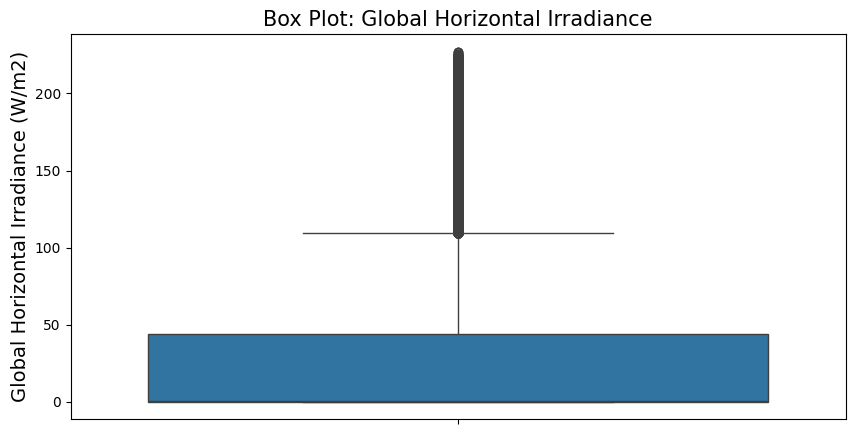

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(rost_clean_df.GHI)
plt.title('Box Plot: Global Horizontal Irradiance', fontsize=15)
plt.ylabel('Global Horizontal Irradiance (W/m2)', fontsize=14)
plt.show()

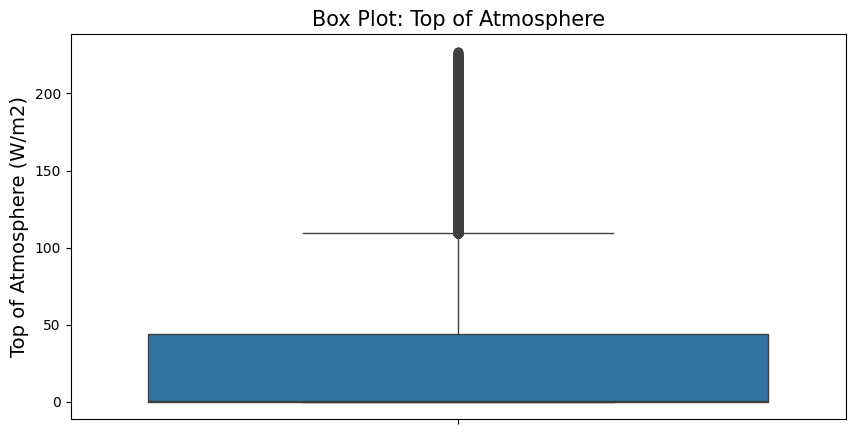

In [ ]:
fig = plt.figure(figsize=(10,5))
sns.boxplot(rost_clean_df.GHI)
plt.title('Box Plot: Top of Atmosphere', fontsize=15)
plt.ylabel('Top of Atmosphere (W/m2)', fontsize=14)
plt.show()

LOF FOR IRRADIATION

In [ ]:
import numpy as np
import pandas as pd
from sklearn.neighbors import LocalOutlierFactor

# Number of neighbors for LOF
n_neighbors = 20

# Dictionary to store the percentage of outliers for each feature
outlier_percentages = {}
contamination = 0.10
# Apply LOF to each feature
for feature in rost_clean_df.columns:
# Reshape the data for LOF
 X = rost_clean_df[[feature]].values

 # Fit the LOF model
 lof = LocalOutlierFactor(n_neighbors=n_neighbors)
 y_pred = lof.fit_predict(X)

 # Identify the outliers
 outliers = y_pred == -1

 # Calculate the percentage of outliers
 percentage_outliers = np.mean(outliers) * 100
 outlier_percentages[feature] = percentage_outliers

 print(f'Percentage of outliers in Freudenstadt irradiation in {feature}: {percentage_outliers:.2f}%')

Percentage of outliers in Freudenstadt irradiation in TOA: 0.03%
Percentage of outliers in Freudenstadt irradiation in Clear sky GHI: 0.01%
Percentage of outliers in Freudenstadt irradiation in Clear sky BHI: 0.09%
Percentage of outliers in Freudenstadt irradiation in Clear sky DHI: 0.01%
Percentage of outliers in Freudenstadt irradiation in Clear sky BNI: 0.01%
Percentage of outliers in Freudenstadt irradiation in GHI: 0.02%
Percentage of outliers in Freudenstadt irradiation in BHI: 0.13%
Percentage of outliers in Freudenstadt irradiation in DHI: 0.01%
Percentage of outliers in Freudenstadt irradiation in BNI: 0.08%


NAIVE BAYES FOR IRRADIATION

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm

# Assuming clean_Osna_Irrad is your DataFrame loaded from your dataset
# Example steps to handle data types and missing values

# Step 1: Check and Convert Data Types
# Convert all columns to numeric (float64)
rost_clean_df =  rost_clean_df.apply(pd.to_numeric, errors='coerce')

# Step 2: Handle Missing Values
rost_clean_df =  rost_clean_df.dropna()  # Drop rows with NaN values

# Extract features
X =  rost_clean_df.values

# Fit Gaussian Naive Bayes model
gnb = GaussianNB()
gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

# Calculate likelihoods for each data point
means = gnb.theta_
variances = np.var(X, axis=0) + 1e-9  # Adding a small value for numerical stability

likelihoods = np.zeros(X.shape[0])

# Ensure means and variances are in correct shape
if means.ndim == 1:
    means = means.reshape(1, -1)
if variances.ndim == 1:
    variances = variances.reshape(1, -1)

# Calculate likelihoods for each data point
for i, x in enumerate(X):
    likelihood = 1
    for j in range(X.shape[1]):
        likelihood *= norm.pdf(x[j], loc=means[0][j], scale=np.sqrt(variances[0][j]))
    likelihoods[i] = likelihood

# Determine anomalies
threshold = np.percentile(likelihoods, 10)  # for example, consider the bottom 10% as anomalies
anomalies = np.where(likelihoods < threshold)[0]

# Calculate percentage of anomalies for each feature
anomalies_rost_clean_df =  rost_clean_df.iloc[anomalies]
total_anomalies = len(anomalies)
total_data_points = len(rost_clean_df)

# Calculate anomaly percentage for each feature
feature_anomalies_percentage = {}
for feature in  rost_clean_df.columns:
    feature_anomalies_count = (anomalies_rost_clean_df[feature] !=  rost_clean_df[feature].mode().iloc[0]).sum()
    feature_anomalies_percentage[feature] = (feature_anomalies_count / total_data_points) * 100

print("Number of anomalies detected:", total_anomalies)
print("Percentage of anomalies for each feature:")
for feature, percentage in feature_anomalies_percentage.items():
    print(f"{feature}: {percentage:.2f}%")


Number of anomalies detected: 17530
Percentage of anomalies for each feature:
TOA: 10.00%
Clear sky GHI: 10.00%
Clear sky BHI: 10.00%
Clear sky DHI: 10.00%
Clear sky BNI: 10.00%
GHI: 10.00%
BHI: 9.99%
DHI: 10.00%
BNI: 9.99%


In [ ]:
rst_df = rost_clean_df.select_dtypes(include=['object']).astype('float')
rst_df['GHI'] = rost_clean_df['GHI']
rst_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 175296 entries, 1546300800000 to 1704066300000
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   TOA            175296 non-null  float64
 1   Clear sky GHI  175296 non-null  float64
 2   Clear sky BHI  175296 non-null  float64
 3   Clear sky DHI  175296 non-null  float64
 4   Clear sky BNI  175296 non-null  float64
 5   BHI            175296 non-null  float64
 6   DHI            175296 non-null  float64
 7   BNI            175296 non-null  float64
 8   GHI            175296 non-null  float64
dtypes: float64(9)
memory usage: 17.4+ MB


NAIVE BAYES 2

In [ ]:
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from scipy.stats import norm



# Initialize a dictionary to store anomaly information for each feature
anomaly_info = {}

# Loop through each feature
for feature in rst_df.columns:
    # Extract the feature values
    X = rst_df[[feature]].values

    # Fit Gaussian Naive Bayes model
    gnb = GaussianNB()
    gnb.fit(X, np.zeros(X.shape[0]))  # Dummy target variable

    # Calculate likelihoods for each data point
    means = gnb.theta_
    variances = gnb.var_
    likelihoods = np.zeros(X.shape[0])

    # Ensure means and variances are in correct shape
    if means.ndim == 1:
        means = means.reshape(1, -1)
    if variances.ndim == 1:
        variances = variances.reshape(1, -1)

    # Calculate likelihoods for each data point
    for i, x in enumerate(X):
        likelihood = norm.pdf(x[0], loc=means[0][0], scale=np.sqrt(variances[0][0]))
        likelihoods[i] = likelihood

    # Determine anomalies using mean and standard deviation
    mean_likelihood = np.mean(likelihoods)
    std_likelihood = np.std(likelihoods)
    threshold = mean_likelihood - 2 * std_likelihood  # 2 standard deviations below the mean
    anomalies = np.where(likelihoods < threshold)[0]

    # Calculate percentage of anomalies for this feature
    total_anomalies = len(anomalies)
    total_data_points = len(rst_df)
    anomaly_percentage = (total_anomalies / total_data_points) * 100

    # Store the anomaly information
    anomaly_info[feature] = {
        'total_anomalies': total_anomalies,
        'anomaly_percentage': anomaly_percentage,
        'anomalies': anomalies
    }

# Print results
for feature, info in anomaly_info.items():
    print(f"Feature: {feature}")
    print(f"  Number of anomalies detected: {info['total_anomalies']}")
    print(f"  Percentage of anomalies: {info['anomaly_percentage']:.2f}%")



Feature: TOA
  Number of anomalies detected: 16364
  Percentage of anomalies: 9.34%
Feature: Clear sky GHI
  Number of anomalies detected: 17291
  Percentage of anomalies: 9.86%
Feature: Clear sky BHI
  Number of anomalies detected: 17519
  Percentage of anomalies: 9.99%
Feature: Clear sky DHI
  Number of anomalies detected: 13229
  Percentage of anomalies: 7.55%
Feature: Clear sky BNI
  Number of anomalies detected: 10151
  Percentage of anomalies: 5.79%
Feature: BHI
  Number of anomalies detected: 16326
  Percentage of anomalies: 9.31%
Feature: DHI
  Number of anomalies detected: 15382
  Percentage of anomalies: 8.77%
Feature: BNI
  Number of anomalies detected: 19512
  Percentage of anomalies: 11.13%
Feature: GHI
  Number of anomalies detected: 17414
  Percentage of anomalies: 9.93%


AUTOENCODER FOR IRRADIATION

In [ ]:
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import Input, Dense
# from sklearn.preprocessing import StandardScaler
# from sklearn.preprocessing import MinMaxScaler
# from keras.models import Sequential



# #to save all features
# features_auto_i = rost_clean_df.columns.tolist()


# # DataFrame to store anomaly scores for each feature
# anomaly_scores_auto_i = pd.DataFrame(index=rost_clean_df.index)

# # Loop through each feature
# for feature in features_auto_i :
#     # Scale the feature data
#     scaler = MinMaxScaler()
#     scaled_feature_auto_i  = scaler.fit_transform(rost_clean_df[[feature]])

#     # Define the autoencoder model
#     model_auto_i  = Sequential([
#         Dense(32, activation='relu', input_shape=(1,)),
#         Dense(16, activation='relu'),
#         Dense(32, activation='relu'),
#         Dense(1, activation='sigmoid')
#     ])

#     model_auto_i .compile(optimizer='adam', loss='mean_squared_error')

#      #Train the autoencoder
#     model_auto_i.fit(scaled_feature_auto_i , scaled_feature_auto_i , epochs=50, batch_size=32, validation_split=0.1, verbose=0)

#     # Get reconstruction loss
#     reconstructed_feature_auto_i  = model_auto_i.predict(scaled_feature_auto_i)
#     reconstruction_loss_auto_i  = np.mean(np.square(scaled_feature_auto_i  - reconstructed_feature_auto_i), axis=1)

#     # Store the reconstruction loss (anomaly score) in the DataFrame
#     anomaly_scores_auto_i [feature] = reconstruction_loss_auto_i



5478/5478 [==============================] - 10s 2ms/step


In [ ]:

# print(reconstruction_loss_auto_i)
# # Calculate the threshold as the 90th percentile of the reconstruction loss
# threshold_auto_i = np.percentile(reconstruction_loss_auto_i, 90)

#     # Identify anomalies
# anomalies_auto_i = reconstruction_loss_auto_i > threshold_auto_i

# for feature in features_auto_i:
#     anomalies_auto_i = anomaly_scores_auto_i[feature] > threshold_auto_i
#     anomaly_percentage_auto_i = np.mean(anomalies_auto_i) * 100
#     print(f'Feature: {feature}, Anomaly Percentage: {anomaly_percentage_auto_i:.2f}%')


#     # Store the reconstruction loss (anomaly score) in the DataFrame
# anomaly_scores_auto_i[feature] = reconstruction_loss_auto_i


# # Combine anomaly scores with original data for easier analysis
# combined_data_auto_i = pd.concat([rost_clean_df, anomaly_scores_auto_i.add_suffix('_anomaly_score')], axis=1)

# # Save the combined data with anomaly scores
# combined_data_auto_i.to_csv('rost_clean_df_with_anomaly_scores_auto_i.csv', index=False)

# # Display the first few rows of the combined data
# combined_data_auto_i.head()






[1.21963218e-08 1.21963218e-08 1.21963218e-08 ... 1.21963218e-08
 1.21963218e-08 1.21963218e-08]
Feature: TOA, Anomaly Percentage: 0.93%
Feature: Clear sky GHI, Anomaly Percentage: 0.01%
Feature: Clear sky BHI, Anomaly Percentage: 0.18%
Feature: Clear sky DHI, Anomaly Percentage: 0.17%
Feature: Clear sky BNI, Anomaly Percentage: 11.83%
Feature: GHI, Anomaly Percentage: 0.96%
Feature: BHI, Anomaly Percentage: 0.30%
Feature: DHI, Anomaly Percentage: 0.31%
Feature: BNI, Anomaly Percentage: 10.00%


,TOA,Clear sky GHI,Clear sky BHI,Clear sky DHI,Clear sky BNI,GHI,BHI,DHI,BNI,TOA_anomaly_score,Clear sky GHI_anomaly_score,Clear sky BHI_anomaly_score,Clear sky DHI_anomaly_score,Clear sky BNI_anomaly_score,GHI_anomaly_score,BHI_anomaly_score,DHI_anomaly_score,BNI_anomaly_score
1546300800000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.928614e-08,1.540157e-08,3.351888e-08,8.805978e-09,1.674495e-07,8.156815e-09,4.455943e-08,4.820397e-08,1.219632e-08
1546301700000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.928614e-08,1.540157e-08,3.351888e-08,8.805978e-09,1.674495e-07,8.156815e-09,4.455943e-08,4.820397e-08,1.219632e-08
1546302600000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.928614e-08,1.540157e-08,3.351888e-08,8.805978e-09,1.674495e-07,8.156815e-09,4.455943e-08,4.820397e-08,1.219632e-08
1546303500000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.928614e-08,1.540157e-08,3.351888e-08,8.805978e-09,1.674495e-07,8.156815e-09,4.455943e-08,4.820397e-08,1.219632e-08
1546304400000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.928614e-08,1.540157e-08,3.351888e-08,8.805978e-09,1.674495e-07,8.156815e-09,4.455943e-08,4.820397e-08,1.219632e-08


XGBOOST ON IRRADIATION DATASET

In [ ]:

from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

# Sample Data (Replace with your dataset)
# Assuming a dataframe with 100 rows and 10 features


# Define anomaly detection function
def detect_anomalies(Mun_df):
    anomalies = pd.DataFrame(index=Mun_df.index)
    anomaly_percentages = {}

    for feature in Mun_df.columns:
        X = Mun_df.drop(columns=[feature])
        y = Mun_df[feature]

        # Train-test split
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # Train XGBoost model
        model = XGBRegressor()
        model.fit(X_train, y_train)

        # Predict on the whole dataset
        y_pred = model.predict(X)

        # Calculate prediction errors
        errors = np.abs(y - y_pred)

        # Determine dynamic threshold using standard deviation
        mean_error = np.mean(errors)
        std_error = np.std(errors)
        threshold = mean_error + 2 * std_error  # Consider 2 standard deviations from the mean

        # Flag anomalies
        anomaly_flags = errors > threshold
        anomalies[feature] = anomaly_flags

        # Calculate anomaly percentage
        anomaly_percentages[feature] = (anomaly_flags.sum() / len(Mun_df)) * 100

        # Print summary
        print(f"Feature: {feature}")
        print(f"Threshold: {threshold:.4f}")
        print(f"Anomalies detected: {anomaly_flags.sum()}/{len(Mun_df)} ({anomaly_percentages[feature]:.2f}%)")
        print("-" * 40)

    return anomalies, anomaly_percentages

# Detect anomalies
anomalies_df, anomaly_percentages = detect_anomalies(rst_df)


# Print anomaly percentages
print("\nAnomaly Percentages per Feature:")
for feature, percentage in anomaly_percentages.items():
    print(f"{feature}: {percentage:.2f}%")


Feature: TOA
Threshold: 1.9298
Anomalies detected: 9486/175296 (5.41%)
----------------------------------------
Feature: Clear sky GHI
Threshold: 0.9430
Anomalies detected: 9911/175296 (5.65%)
----------------------------------------
Feature: Clear sky BHI
Threshold: 0.8466
Anomalies detected: 10037/175296 (5.73%)
----------------------------------------
Feature: Clear sky DHI
Threshold: 1.2503
Anomalies detected: 9761/175296 (5.57%)
----------------------------------------
Feature: Clear sky BNI
Threshold: 4.0628
Anomalies detected: 10192/175296 (5.81%)
----------------------------------------
Feature: BHI
Threshold: 0.9008
Anomalies detected: 9625/175296 (5.49%)
----------------------------------------
Feature: DHI
Threshold: 1.2314
Anomalies detected: 8641/175296 (4.93%)
----------------------------------------
Feature: BNI
Threshold: 2.6182
Anomalies detected: 8772/175296 (5.00%)
----------------------------------------
Feature: GHI
Threshold: 1.1020
Anomalies detected: 8459/175296